In [1]:
!pip install --upgrade --pre xee

In [2]:
!pip install -U geemap

In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url='https://earthengine-highvolume.googleapis.com')

In [5]:
import geemap

In [6]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [7]:
roi = map.draw_last_feature.geometry()

In [8]:
budic = (ee.FeatureCollection("WM/geoLab/geoBoundaries/600/ADM2")
.filterBounds(roi)
)

map.addLayer(budic)

In [9]:
vec = geemap.ee_to_gdf(budic)
vec

,geometry,shapeGroup,shapeID,shapeName,shapeType
0,"POLYGON ((33.00003 4.48026, 33.05195 4.41562, ...",SSD,79223893B70583427213056,Budi,ADM2


In [10]:
def ndvi(img):
  prob = img.select("probability")
  clear_pixels = prob.lt(30)
  sr = img.select("B.*", "MSK_CLDPRB").multiply(0.0001)
  # Renaming for consistency with xarray
  sr = sr.select(["B4", "B8"], ["red", "nir"])
  index = sr.normalizedDifference(["nir", "red"]).rename("ndvi")
  stack = ee.Image.cat([sr.select(["red", "nir"]), index]).updateMask(clear_pixels)
  return stack

In [11]:
sen2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"), "probability"
    )
    .filterDate("2020", "2025")
    .filterBounds(roi)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(ndvi)
    .median()
)

sen2

In [12]:
from shapely.geometry import shape

In [13]:
vec = shape(roi.getInfo())

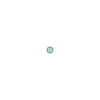

In [14]:
vec

In [15]:
from xee import helpers

In [16]:

grid_params = helpers.fit_geometry(
    geometry = vec,
    geometry_crs = "EPSG:4326",
    buffer = 500,
    grid_crs = "EPSG: 3857",
    grid_scale = (30, -30)
)

In [17]:
import xarray as xr

In [18]:
ds = xr.open_dataset(
    sen2,
    engine = "ee",
    **grid_params
)

In [19]:
ds = ds.squeeze("time").drop_vars("time") * 1

In [20]:
import matplotlib.pyplot as plt

In [21]:
ds

<xarray.Dataset> Size: 15kB
Dimensions:  (y: 35, x: 35)
Coordinates:
  * y        (y) float64 280B 4.755e+05 4.755e+05 ... 4.745e+05 4.745e+05
  * x        (x) float64 280B 3.745e+06 3.745e+06 ... 3.746e+06 3.746e+06
Data variables:
    red      (y, x) float32 5kB 0.05325 0.0377 0.04368 ... 0.05875 0.05505
    nir      (y, x) float32 5kB 0.3355 0.3082 0.2957 ... 0.3338 0.3209 0.2997
    ndvi     (y, x) float32 5kB 0.722 0.7867 0.7507 ... 0.7171 0.6681 0.6919

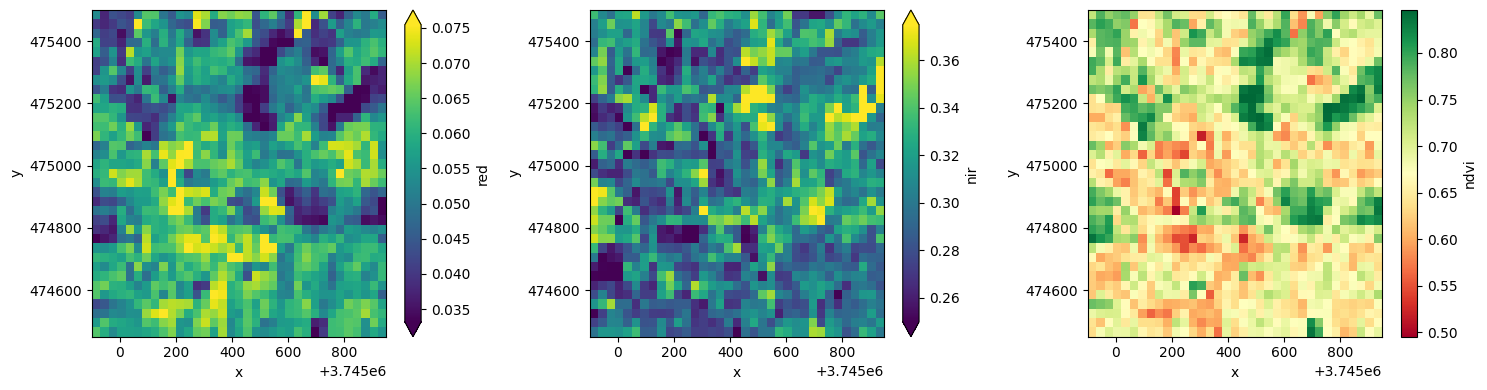

In [22]:
fig, ax = plt.subplots(1, 3, figsize = (15, 4))

ds.red.plot(x = "x", y = "y", ax = ax[0], robust = True)
ds.nir.plot(x = "x", y = "y", ax = ax[1], robust = True)
ds.ndvi.plot(x = "x", y = "y", ax = ax[2],cmap = "RdYlGn")



plt.tight_layout()

In [23]:
red_vals = ds.red.values.flatten()
nir_vals = ds.nir.values.flatten()
ndvi_vals = ds.ndvi.values.flatten()

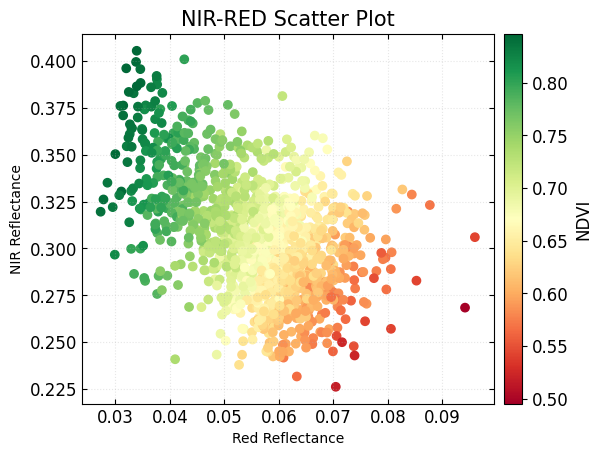

In [24]:
fig, ax = plt.subplots()

scatter = ax.scatter(x = red_vals, y = nir_vals, c = ndvi_vals, cmap = "RdYlGn")
cbar = fig.colorbar(scatter, ax = ax, cmap = "RdYlGn", pad = 0.02)
cbar.set_label("NDVI", fontsize = 12)
cbar.ax.tick_params(labelsize = 12)
ax.set_ylabel("NIR Reflectance")
ax.set_xlabel("Red Reflectance")
ax.set_title("NIR-RED Scatter Plot", fontsize = 15)
ax.tick_params(axis = "both", direction = "in", right = True, top = True, labelsize = 12)
ax.grid(ls = ":", alpha = 0.3)

plt.savefig("ndvi_scatter.png", dpi = 360, bbox_inches = 'tight' )
